# Explorative Datenanalyse der Vorher- Nachherbilder 

## Gedanken hinter den Analysen

Im Kern wollen wir aus den beiden Bildern (vorher/nachher) genau die gleiche Region extrahieren, dann diese Region binarisieren und schliesslich zählen, wie viele Pixel im “nachher”-Bild noch Kleber sind im Vergleich zum “vorher”-Bild. So könnten wir bestimmen, wieviel Prozent der Kleberaupe haften geblieben ist und sie anhand dieser Erkenntniss klassifizieren. 

In diesem Notebook wollen wir testen, ob die Bilder überhaupt für einen solchen Ansatz geeignet sind, oder ob es noch Anpassungen in der Umsetzung braucht. 

In [ ]:
# read libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Vorher- Nachherbild vergleichen

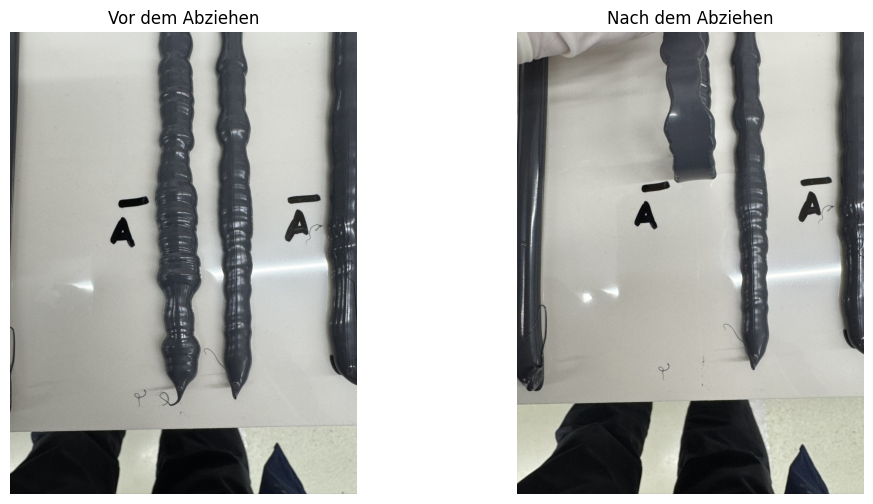

In [ ]:
# read example images
vorher = cv2.imread('images/IMG_9219.JPEG')
nachher = cv2.imread('images/IMG_9220.JPEG')

# image from BGR to RGB for correct display with matplotlib
img_vorher = cv2.cvtColor(vorher, cv2.COLOR_BGR2RGB)
img_nachher = cv2.cvtColor(nachher, cv2.COLOR_BGR2RGB)

# show images before and after subtraction
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Vor dem Abziehen")
plt.imshow(img_vorher)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Nach dem Abziehen")
plt.imshow(img_nachher)
plt.axis('off')

plt.show()

In der Abbildung sehen wir die Kleberaupe vor und nach dem Abziehen. Anhand von den beiden Bildern soll später errechnet werden, wieviel Prozent noch auf der Unterlage haften geblieben ist. 

### Umwandlung in Graustufenform

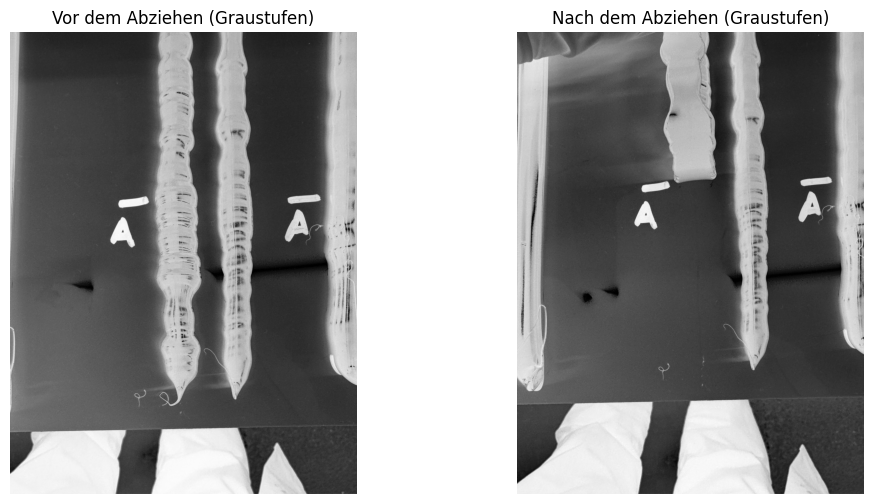

In [2]:
# convert images to grayscale
gray = cv2.cvtColor(img_vorher, cv2.COLOR_BGR2GRAY)
gray_nachher = cv2.cvtColor(img_nachher, cv2.COLOR_BGR2GRAY)

# invert grayscale images for better visibility
gray_inv = cv2.bitwise_not(gray)
gray_inv_nachher = cv2.bitwise_not(gray_nachher)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Vor dem Abziehen (Graustufen)")
plt.imshow(gray_inv, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Nach dem Abziehen (Graustufen)")
plt.imshow(gray_inv_nachher, cmap='gray')
plt.axis('off')
plt.show()

### Bilder in Binär umwandeln für Vergleich der Pixelwerte

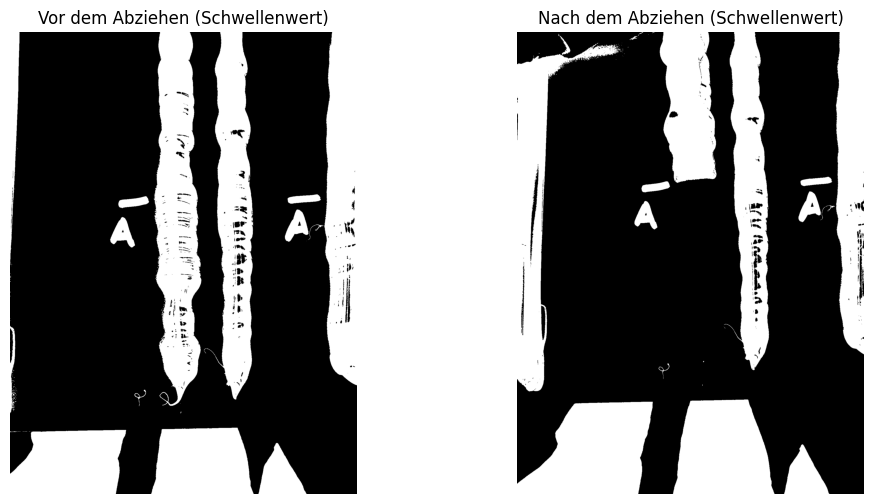

In [3]:
# thresholding to create binary images
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)
_, thresh_nachher = cv2.threshold(gray_nachher, 120, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Vor dem Abziehen (Schwellenwert)")
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Nach dem Abziehen (Schwellenwert)")
plt.imshow(thresh_nachher, cmap='gray')
plt.axis('off')
plt.show()

Auf diesem Schwarz-Weiss Bild ist gut zu erkennen, dass sich der Klebestreiffen komplett von der Unterlage gelöst hat. Was für eine Pixelzählung aber zum Problem werden könnte, ist dass die Bilder aus unterschiedlichen Winkel und anderer Entfernung aufgenommen wurden. Um dies zu Prüfen werden wir die Absolute Differenz der Bilder plotten.  

### Berechnung der Pixeldifferenz in den Bildern

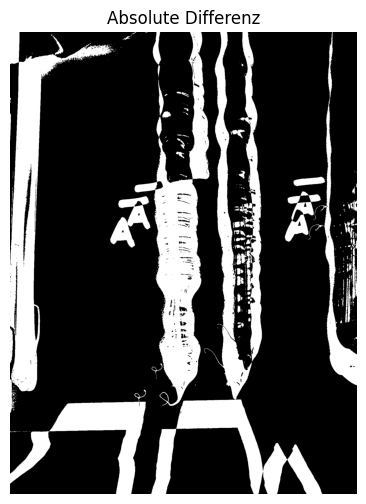

In [4]:
# difference between the two binary images
diff = cv2.absdiff(thresh, thresh_nachher)
plt.figure(figsize=(6, 6))
plt.title("Absolute Differenz")
plt.imshow(diff, cmap='gray')
plt.axis('off')
plt.show()

Es ist in der Abbildung ganz klar ersichtlich, dass die beiden Bilder aus verschiedenen Winkel aufgenommen wurden und somit keine verlässliche Differenz der Pixel berechnet werden kann.

### Finden von Keypoints mit Hilfe des ORB-Algorithmus

Wir werden nun versuchen die Bilder gleichzusetzen in dem wir ORB anwenden, welcher Keypoints in den Bildern erkennen soll. Anhand dieser Keypoints werden wir dann die Bilder justieren, dass sie gleich aufeinander liegen.

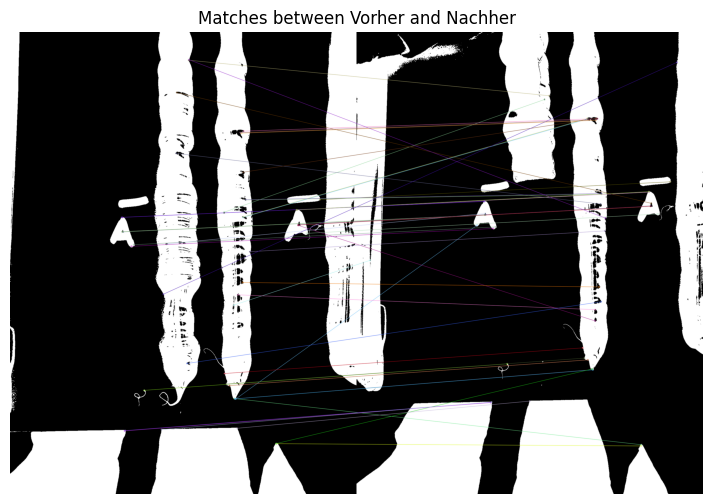

In [5]:
# use ORB to find keypoints and descriptors and allign them
orb = cv2.ORB_create()
keypoints_vorher, descriptors_vorher = orb.detectAndCompute(thresh, None)
keypoints_nachher, descriptors_nachher = orb.detectAndCompute(thresh_nachher, None)
# create a matcher to find the best matches between the two sets of descriptors
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptors_vorher, descriptors_nachher)
# sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)
# draw the matches on the images
img_matches = cv2.drawMatches(thresh, keypoints_vorher, thresh_nachher, keypoints_nachher, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(12, 6))
plt.title("Matches between Vorher and Nachher")
plt.imshow(img_matches)
plt.axis('off')
plt.show()

In dieser Grafik sind die Top 50 Keypoints erkennbar, anhand derer die Bilder nun angepasst werden können.

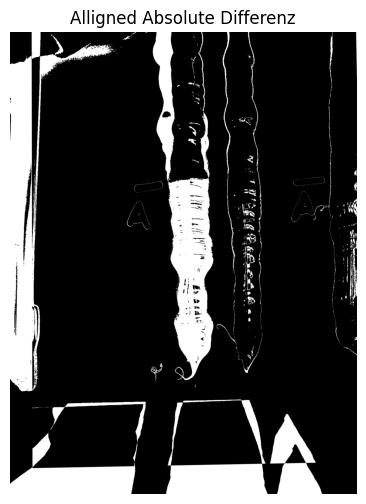

In [6]:
# allign the images using the matches and plot absolute difference
src_pts = np.float32([keypoints_vorher[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([keypoints_nachher[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
# warp the first image to the second image
h, w = thresh_nachher.shape
warped_vorher = cv2.warpPerspective(thresh, M, (w, h))
# calculate the absolute difference between the warped image and the second image
diff_alligned = cv2.absdiff(warped_vorher, thresh_nachher)
plt.figure(figsize=(6, 6))
plt.title("Alligned Absolute Differenz")
plt.imshow(diff_alligned, cmap='gray')
plt.axis('off')
plt.show()

In der Grafik wurden die Bilder übereinander gelegt und die absolute Differenz der Pixelwerte ausgegeben. Die Weissen Abschnitte auf den Bildern sind die Differenz. Darin ist zu erkennen, dass links plötzlich einen neue Kleberaupe hinzugekommen ist auf dem Nachherbild und dass es grosse unterschiede gibt bei den Beinen des Mitarbeiters. Auch ist auffällig, dass es in der abgezogenen Kleberaupe oben eine grosse differnez gibt. Diese ergibt sich daraus, dass der Mitarbeiter die Kleberaupe hoch hält und nicht abgeschnitten hat.

Zusammengefasst würde eine Berechnung der Differenz gorsse Varianz in der Genauigkeit aufweisen, da die Vorher- Nachherbilder nicht einheitlich und unter den gleichen Bedingungen aufgenommen wurden. 


## Fazit: Standardisierte Aufnahmen mit der Fotobox

Um für die Vorher- Nachherbilder eine standartisierte Methode und somit gleiche Begebenheiten zu gewährleisten, haben wir eine Fotobox gebaut, welche es den Mitarbeitern ermöglicht das Smartphone aufzulegen und die Unterlage mit den Kleberaupten einmal vor den Tests und einmal nach den Tests rein zu legen und aus den genau gleichen Winkeln zu fotografieren. Dieses Verfahren vereinfacht die Arbeit mit dem Non-Deep-Learning Ansatz extrem und sorgt für Reproduzierbarkeit.